<a href="https://colab.research.google.com/github/mwetmore05/A02-eda-and-visualization/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maggie Wetmore

**Date:** 9/926

In [5]:
# Your Phase 1 solution to the problem goes here.

#1.

See the file uploaded to repository.

#2.1.

In [6]:
import pandas as pd #importing packages
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
FG = pd.read_csv('/content/ForeignGifts_edu.csv') #downloading the data
FG.head()

FG['Foreign Gift Amount'] = pd.to_numeric( #cleaning the data by assuring no , or $
    FG['Foreign Gift Amount']
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False),
    errors='coerce'
)

#2.2.

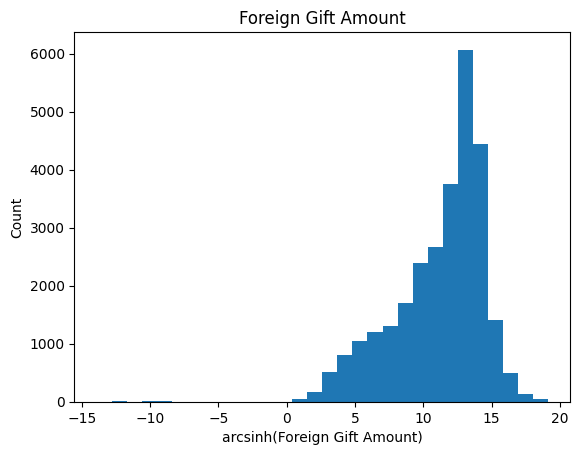

In [7]:
FG["Foreign Gift Amount"] = np.arcsinh(FG["Foreign Gift Amount"]) #tranforming for the long tail fo the histogram like we did in class
FG["Foreign Gift Amount"].hist(bins=30, grid=False)
plt.title("Foreign Gift Amount") #labeling the histogram
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Count")
plt.show()


Findings: left skewed histogram. One peak. There could be potential outliars given the visual skewedness.

#2.3.

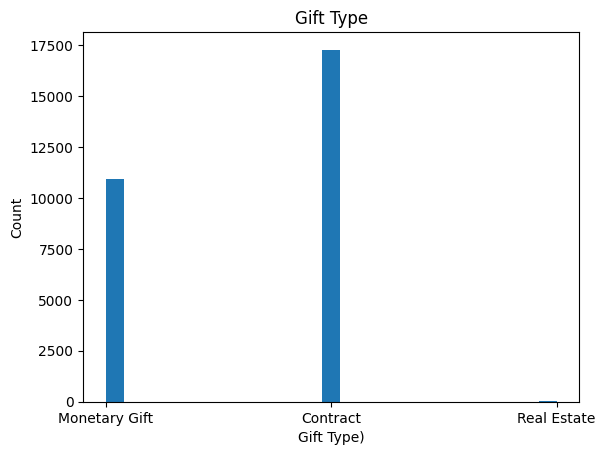

Proportion of Monetary Gifts in Foreign Gift's: 0.3875128450444704
Proportion of Contracts in Foreign Gift's: 0.6120973742957372
Proportion of Real Estate in Foreign Gift's: 0.00038978065979235324


In [8]:
 #tranforming for the long tail fo the histogram like we did in class
FG["Gift Type"].hist(bins=25, grid=False) #mkaing histogram no grid, and 25 bins
plt.title("Gift Type")
plt.xlabel("Gift Type)")
plt.ylabel("Count")
plt.show()


Monetary_Gift_proportion = (
    FG["Gift Type"] == "Monetary Gift").sum() / len(FG["Gift Type"])

print("Proportion of Monetary Gifts in Foreign Gift's:", Monetary_Gift_proportion)

Contract_proportion = (
    FG["Gift Type"] == "Contract").sum() / len(FG["Gift Type"])

print("Proportion of Contracts in Foreign Gift's:", Contract_proportion)

Real_Estate_proportion = (
    FG["Gift Type"] == "Real Estate").sum() / len(FG["Gift Type"]) #calculating the sum of real estate/ contract/ monetary gift (what I did i the previous lines) / total gift types

print("Proportion of Real Estate in Foreign Gift's:", Real_Estate_proportion) #printing out labels and proprotion with it

#2.4.

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


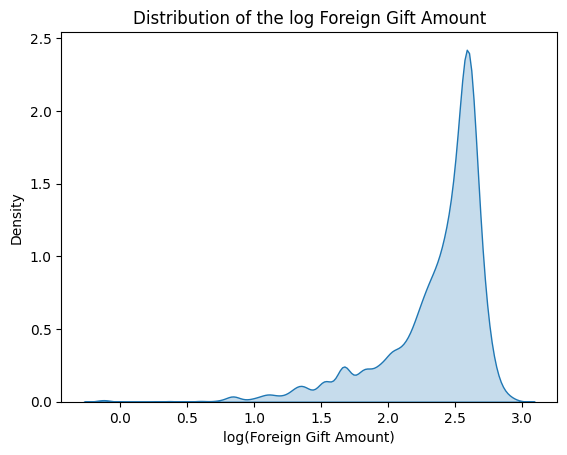

In [9]:
FG['Log Foreign Gift Amount'] = np.log(  #getting log from pandas
    FG['Foreign Gift Amount']) #logging with np the foreign gift amount

sns.kdeplot( #kernel density plot of log of foreign gift amount
    data=FG,
    x='Log Foreign Gift Amount',
    fill=True) #filling because looks better

plt.title('Distribution of the log Foreign Gift Amount') #labeling
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

Findings:left skwed, single peak. still not symmetric.

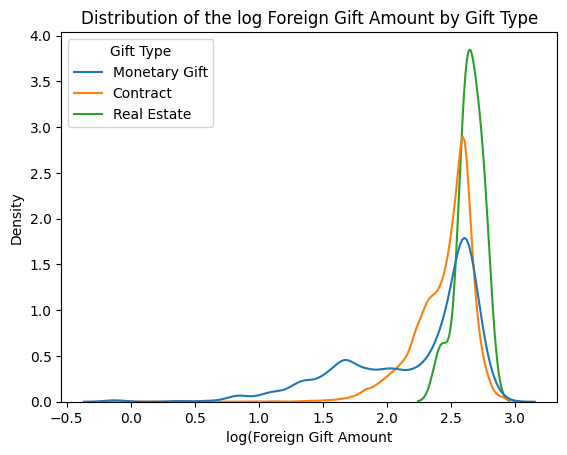

In [10]:
#now same but conditional on gift type
sns.kdeplot(
    data=FG,
    x='Log Foreign Gift Amount',
    hue='Gift Type', #conditional statement
    common_norm=False)

plt.title('Distribution of the log Foreign Gift Amount by Gift Type') #labeling!
plt.xlabel('log(Foreign Gift Amount')
plt.ylabel('Density')
plt.show()

The log transformation reduces the strong skew in the histogram/KDE that is seem in the previous lot. It still has a long tail but toward smaller amounts. When the foreign gift amounts are seperated by gift types the reak esatet is the smalled amount and narrowest distribution, compared to the contract with more concentrated large amounts. But the proportion of contracts is about .0003 so that is very important to note when doing further analysis.

#2.5.

In [11]:
top_15_giftgivers_by_count = (
    FG['Country of Giftor']
    .value_counts()
    .head(15)) #creating top 15 names and top counts and showing top 15

top_15_giftgivers_by_count

,count
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [12]:
top_15_giftgivers_by_amount = (
    FG.groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False) #grouping by foreign gift amiunt, summing all the gifts to show total  15
    .head(15))

top_15_giftgivers_by_amount

,Foreign Gift Amount
Country of Giftor,
ENGLAND,36809.943101
CHINA,28225.510982
CANADA,21333.704080
JAPAN,20751.397037
SAUDI ARABIA,19347.062506
SWITZERLAND,19071.613687
FRANCE,15599.092109
GERMANY,14738.055125
HONG KONG,12459.739488


#2.6

In [13]:
top_15_gifters = (
    FG.groupby('Giftor Name')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False) #showing total froeign gift amount top giftor names
    .head(15))

top_15_gifters

,Foreign Gift Amount
Giftor Name,
Saudi Arabian Cultural Mission,5619.041181
Qatar Foundation,3723.179372
Anonymous,3646.566941
Human Frontier Science Program,2677.252901
Novartis Pharmaceuticals Corp,2255.583706
Royal Embassy of Saudi Arabia,2208.716884
Acerta Pharma B.V.,2078.507347
Contracting Party,1861.464939
Qatar National Research Fund,1656.435430


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 3ed1e55be6506895e4bfa12f885e57552219831b
- **AI tool and model used:** CHAT GPT-5.6 Sol

### *Prompts used

1. What errors are in this code/ how can i enhance it? (For 2.1-2.2)
2. Is there any neccesary changes i need to make so my code runs smoother (I did not want to get too many suggestions this time) (For 2.3-2.4)
3. Do you think i need/ show fix these in any way? (For 2.5-2.6)

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

#1.
Your code runs, but there is one important problem: you overwrite the original gift amounts with the transformed values. That means any later totals or rankings would incorrectly use arcsinh(amount) instead of the actual dollar amount.

Use a new column for the transformation:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FG = pd.read_csv("/content/ForeignGifts_edu.csv")

##1a Convert gift amounts from text to numbers
FG["Foreign Gift Amount"] = pd.to_numeric(
    FG["Foreign Gift Amount"]
      .astype(str)
      .str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

##1b Check for values that could not be converted
print("Missing/invalid amounts:", FG["Foreign Gift Amount"].isna().sum())
print("Negative amounts:", (FG["Foreign Gift Amount"] < 0).sum())

##1c Preserve the original dollar amount
FG["arcsinh_gift_amount"] = np.arcsinh(FG["Foreign Gift Amount"])

plt.figure(figsize=(8, 5))
plt.hist(
    FG["arcsinh_gift_amount"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Foreign Gift Amounts")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Number of Gifts")
plt.tight_layout()
plt.show()

## 1d Other changes I would make:

Your comment says “downloading the data,” but read_csv() is loading it.
Your cleaning comment should say “removing $ and commas.”
If the assignment specifically requests a log transformation, arcsinh() does not meet that requirement. You would instead use:

##1e Other changes I would make:

Your comment says “downloading the data,” but read_csv() is loading it.
Your cleaning comment should say “removing $ and commas.”
If the assignment specifically requests a log transformation, arcsinh() does not meet that requirement. You would instead use:

Don’t say there are outliers solely because the graph is skewed. Skewness and outliers are different things.

## 1f A stronger findings statement would be:

The transformed distribution is unimodal and negatively skewed, with most observations concentrated around transformed values of 12–15 and a longer tail toward smaller values. A small number of extremely low or negative observations may warrant further investigation, but additional numerical checks are needed before classifying them as outliers.

Also, the original gift amounts are likely right-skewed; it is the transformed values shown here that appear left-skewed.

#2.
Yes—two necessary changes:

##2a. Make sure you do not overwrite "Foreign Gift Amount" with the arcsinh transformation. After fixing that earlier cell, restart the runtime and run all cells again. Otherwise, your log graph is taking the log of already-transformed values.
##2b. Your warning appears because logarithms cannot be calculated for zero or negative amounts. Replace your log code with:
FG["Log Foreign Gift Amount"] = np.log(
    FG["Foreign Gift Amount"].where(FG["Foreign Gift Amount"] > 0)
)

sns.kdeplot(
    data=FG,
    x="Log Foreign Gift Amount",
    fill=True
)

plt.title("Distribution of the Log Foreign Gift Amount")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

For the graph by gift type, use:

sns.kdeplot(
    data=FG,
    x="Log Foreign Gift Amount",
    hue="Gift Type",
    fill=False,
    common_norm=False
)

plt.title("Distribution of the Log Foreign Gift Amount by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

Your proportion code will run correctly. The only optional improvement is dividing by the number of nonmissing gift types:

total_gifts = FG["Gift Type"].notna().sum()

Monetary_Gift_proportion = (
    FG["Gift Type"].eq("Monetary Gift").sum() / total_gifts
)

Contract_proportion = (
    FG["Gift Type"].eq("Contract").sum() / total_gifts
)

Real_Estate_proportion = (
    FG["Gift Type"].eq("Real Estate").sum() / total_gifts
)

Most important: fix the overwritten column, restart the runtime, and run everything from the beginning.
#3.
##3a.Your code in 2.5 and 2.6 is logically correct, but the displayed totals are wrong. Values such as 36,809 show that the code is summing the previously transformed amounts rather than the original dollar amounts.

You do not need to rewrite these cells. You need to:

Confirm the earlier cell uses:
FG["arcsinh_gift_amount"] = np.arcsinh(FG["Foreign Gift Amount"])

and does not overwrite "Foreign Gift Amount".

Restart the runtime.
Run every cell again from the beginning.

Then these existing cells should produce actual dollar totals:

top_15_giftgivers_by_count = (
    FG["Country of Giftor"]
    .value_counts()
    .head(15)
)

top_15_giftgivers_by_count
top_15_giftgivers_by_amount = (
    FG.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_15_giftgivers_by_amount
top_15_giftgivers = (
    FG.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_15_giftgivers

After rerunning, the totals should represent actual dollar amounts and will probably be much larger. The country-count results are already correct.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1a | Accept | I deifnitely shouldve done this given they are numbers for their data type |
| 1b | Accept| Definitey shouldve done this again. it is an important step in data clenaing i forgot |
| 1c | Accept | Definitey shouldve done this again. it is an important step in data clenaing i forgot |
| 1d | reject | I do not want to update my comments and decisions I made, based on my opinion and analysis I only want to update/ improve code|
| 1e |  reject | Again,  do not want to update my comments and decisions I made, based on my opinion and analysis I only want to update/ improve code |
| 1f | reject | Again,  do not want to update my comments and decisions I made, based on my opinion and analysis I only want to update/ improve code |
| 2a | Accept | I did not consider this again and I do not want me log graph to take the log of already-transformed values |
| 2b | Accept | This is a neccesary step, I did not even see the warning and consider that a log cannot be negative when I coded this |
| 3a | Accept | This was the same suggestion in 2a because renaming the variable messed up my values. so accept and do not change the variable to get the correct values for these questions |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [14]:
# Your Phase 2 solution to the problem goes here.


#2.1-2.2

Missing/invalid amounts: 0
Negative amounts: 24


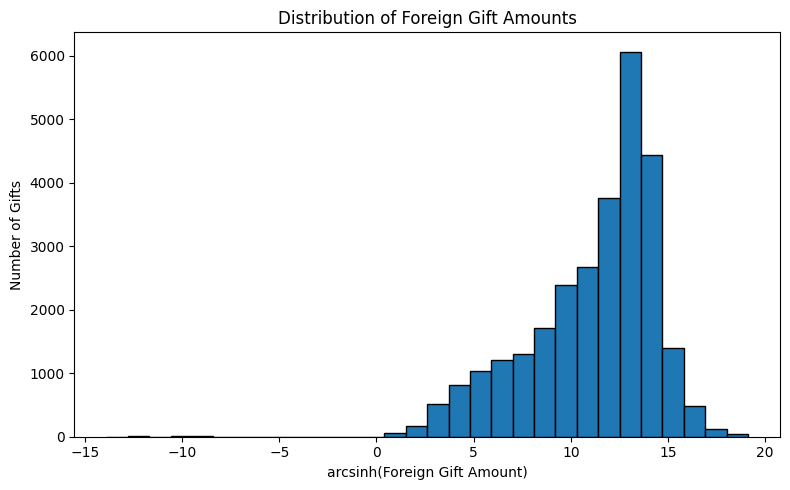

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FG = pd.read_csv("/content/ForeignGifts_edu.csv")
FG.head()

#1a convert gift amounts from text to numbers
FG["Foreign Gift Amount"] = pd.to_numeric(
    FG["Foreign Gift Amount"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

#1b check for values that could not be converted
print("Missing/invalid amounts:", FG["Foreign Gift Amount"].isna().sum())
print("Negative amounts:", (FG["Foreign Gift Amount"] < 0).sum())

#1c preserve the original dollar amount
FG["arcsinh_gift_amount"] = np.arcsinh(FG["Foreign Gift Amount"])

plt.figure(figsize=(8, 5))
plt.hist(
    FG["arcsinh_gift_amount"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Foreign Gift Amounts")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Number of Gifts")
plt.tight_layout()
plt.show()

#2.3-2.4

Missing/invalid amounts: 0
Negative amounts: 24


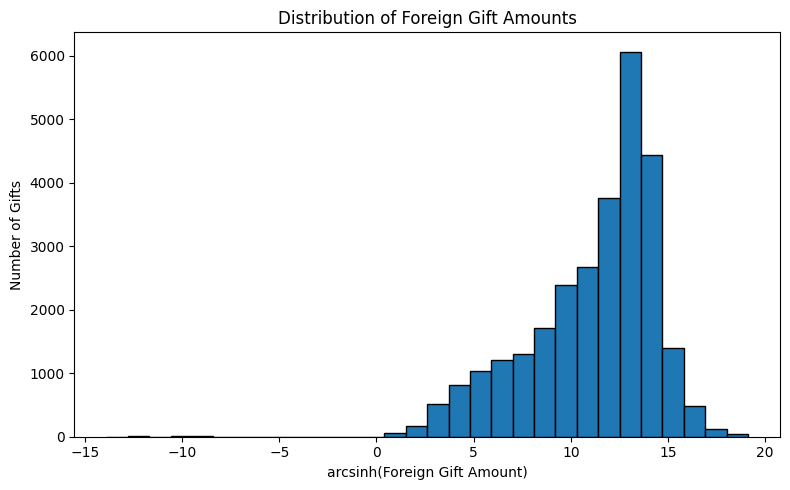

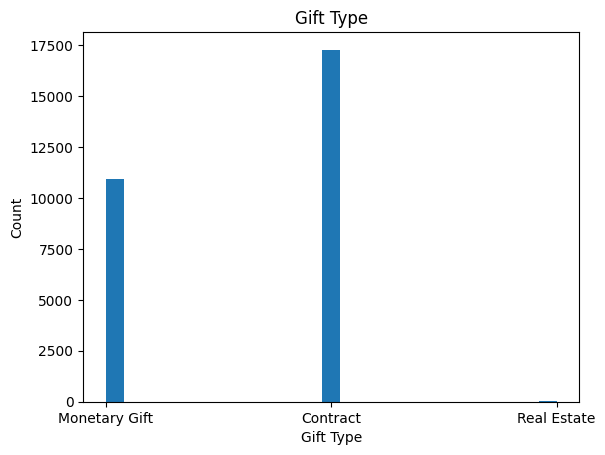

Proportion of Monetary Gifts in Foreign Gifts: 0.3875128450444704
Proportion of Contracts in Foreign Gifts: 0.6120973742957372
Proportion of Real Estate in Foreign Gifts: 0.00038978065979235324


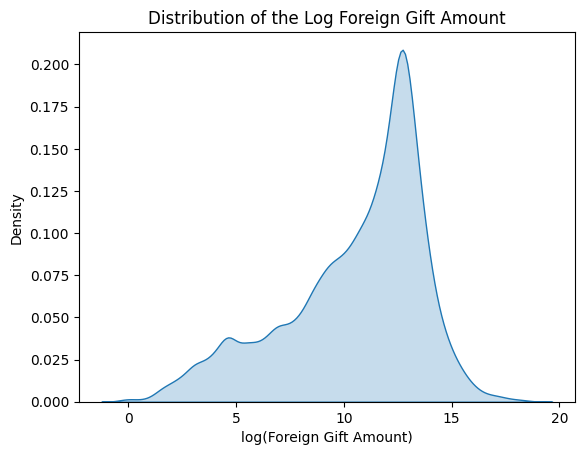

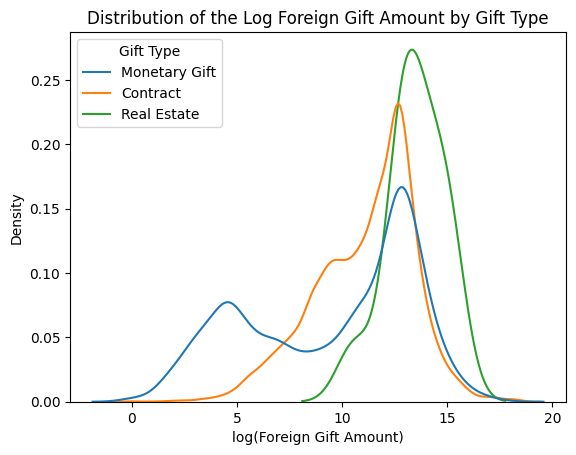

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FG = pd.read_csv("/content/ForeignGifts_edu.csv")
FG.head()

FG["Foreign Gift Amount"] = pd.to_numeric(
    FG["Foreign Gift Amount"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

print("Missing/invalid amounts:", FG["Foreign Gift Amount"].isna().sum())
print("Negative amounts:", (FG["Foreign Gift Amount"] < 0).sum())

#2a fix:creates a new transformed column instead of overwriting the original dollar amounts
FG["arcsinh_gift_amount"] = np.arcsinh(FG["Foreign Gift Amount"])

plt.figure(figsize=(8, 5))
plt.hist(
    FG["arcsinh_gift_amount"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Foreign Gift Amounts")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Number of Gifts")
plt.tight_layout()
plt.show()

FG["Gift Type"].hist(bins=25, grid=False)
plt.title("Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

Monetary_Gift_proportion = (
    FG["Gift Type"] == "Monetary Gift"
).sum() / len(FG["Gift Type"])

print(
    "Proportion of Monetary Gifts in Foreign Gifts:",
    Monetary_Gift_proportion
)

Contract_proportion = (
    FG["Gift Type"] == "Contract"
).sum() / len(FG["Gift Type"])

print(
    "Proportion of Contracts in Foreign Gifts:",
    Contract_proportion
)

Real_Estate_proportion = (
    FG["Gift Type"] == "Real Estate"
).sum() / len(FG["Gift Type"])

print(
    "Proportion of Real Estate in Foreign Gifts:",
    Real_Estate_proportion
)

#2b fix: excludes zero and negative amounts because their logarithms are undefined
FG["Log Foreign Gift Amount"] = np.log(
    FG["Foreign Gift Amount"].where(FG["Foreign Gift Amount"] > 0)
)

sns.kdeplot(
    data=FG,
    x="Log Foreign Gift Amount",
    fill=True
)

plt.title("Distribution of the Log Foreign Gift Amount")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

sns.kdeplot(
    data=FG,
    x="Log Foreign Gift Amount",
    hue="Gift Type",
    fill=False,
    common_norm=False
)

plt.title("Distribution of the Log Foreign Gift Amount by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

#2.5-2.6

Missing/invalid amounts: 0
Negative amounts: 24


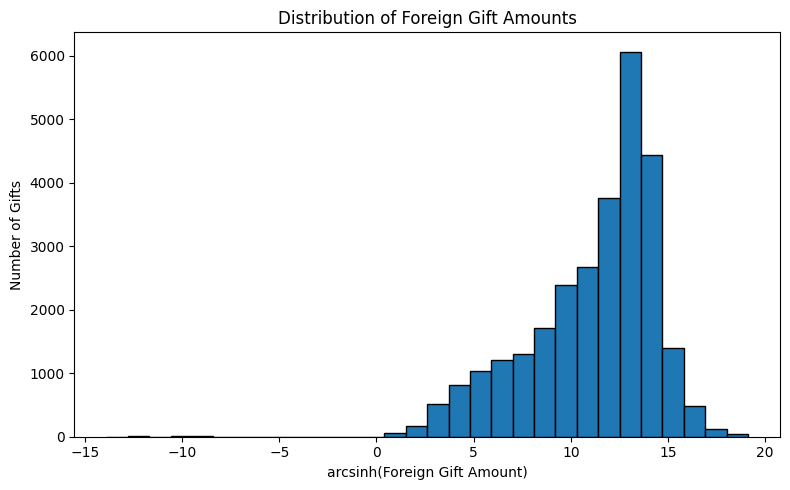

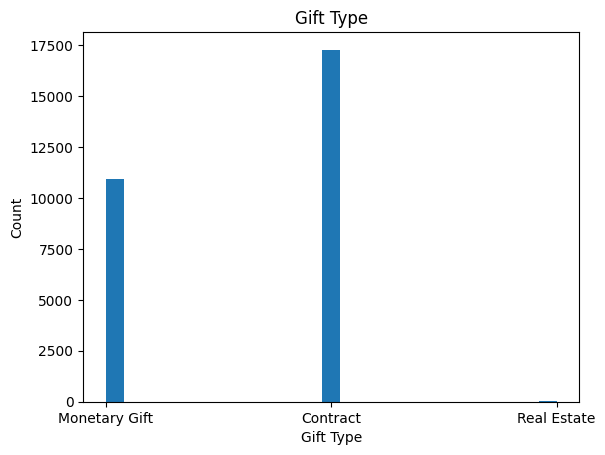

Proportion of Monetary Gifts in Foreign Gifts: 0.3875128450444704
Proportion of Contracts in Foreign Gifts: 0.6120973742957372
Proportion of Real Estate in Foreign Gifts: 0.00038978065979235324


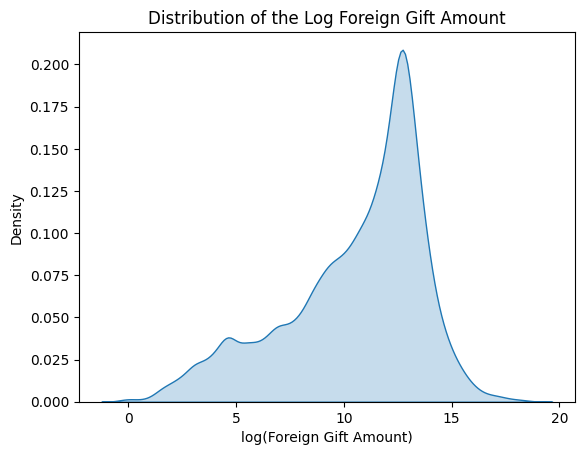

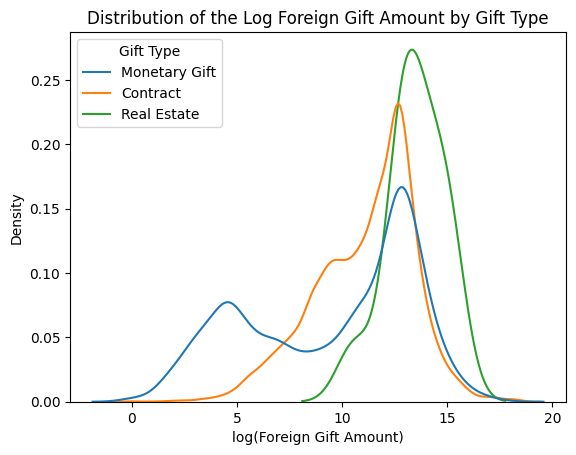

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FG = pd.read_csv("/content/ForeignGifts_edu.csv")
FG.head()

FG["Foreign Gift Amount"] = pd.to_numeric(
    FG["Foreign Gift Amount"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

print("Missing/invalid amounts:", FG["Foreign Gift Amount"].isna().sum())
print("Negative amounts:", (FG["Foreign Gift Amount"] < 0).sum())


#3a/2a fix: going back to correct variable instead of transformed
FG["arcsinh_gift_amount"] = np.arcsinh(FG["Foreign Gift Amount"])

plt.figure(figsize=(8, 5))

plt.hist(
    FG["arcsinh_gift_amount"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Foreign Gift Amounts")
plt.xlabel("arcsinh(Foreign Gift Amount)")
plt.ylabel("Number of Gifts")
plt.tight_layout()
plt.show()


FG["Gift Type"].hist(bins=25, grid=False)

plt.title("Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Count")
plt.show()

Monetary_Gift_proportion = (
    FG["Gift Type"] == "Monetary Gift"
).sum() / len(FG["Gift Type"])

print(
    "Proportion of Monetary Gifts in Foreign Gifts:",
    Monetary_Gift_proportion
)

Contract_proportion = (
    FG["Gift Type"] == "Contract"
).sum() / len(FG["Gift Type"])

print(
    "Proportion of Contracts in Foreign Gifts:",
    Contract_proportion
)

Real_Estate_proportion = (
    FG["Gift Type"] == "Real Estate"
).sum() / len(FG["Gift Type"])

print(
    "Proportion of Real Estate in Foreign Gifts:",
    Real_Estate_proportion
)


#3a/2a fix: going back to correct variable instead of transformed
FG["Log Foreign Gift Amount"] = np.log(
    FG["Foreign Gift Amount"].where(FG["Foreign Gift Amount"] > 0)
)

sns.kdeplot(
    data=FG,
    x="Log Foreign Gift Amount",
    fill=True
)

plt.title("Distribution of the Log Foreign Gift Amount")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()


sns.kdeplot(
    data=FG,
    x="Log Foreign Gift Amount",
    hue="Gift Type",
    fill=False,
    common_norm=False
)

plt.title("Distribution of the Log Foreign Gift Amount by Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()


top_15_giftgivers_by_count = (
    FG["Country of Giftor"]
    .value_counts()
    .head(15)
)

top_15_giftgivers_by_count


#3a/2a fix: going back to correct variable instead of transformed
top_15_giftgivers_by_amount = (
    FG.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_15_giftgivers_by_amount

#3a/2a fix: going back to correct variable instead of transformedr
top_15_giftgivers = (
    FG.groupby("Giftor Name")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_15_giftgivers

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements using AI vs non AI made a huge difference in this assignment. It minded me and helped me perserve the original dollar amounts by creating a seperate arcsinh_gift_amount column. Which made all my further calcualtions correct for gift types and gift amounts because before they were way off and I did not even realize. It also prevented invalid logs, by preventing any negative numbers to be logged so I would not get an error. It also helped me clean my data further by correcting the country and gift totals to use actual dollars rather than a different data type. AI did have some limitations like trying to reevaluate my comments and interpretations which I did not want it to do but that could have been my fault I was not more clear. I also need to make sure I evaluate each recommendation instead of just taking them automatically, but this time AI gave me very valid recommendations that I used a lot of. To verify I restarted the runtime and ran the notbook from the beginnging and confirmed that no log warning appeared. I also confirmed that the dollar values were realistic rather than the smaller transformed values I messed up originally. AI is definitely a tool that helped me enhance and fix my code but again I need to remain warry of it for all my use of it in the future.